### Análisis de datos II
## EDA dataset Automotive

1985 Ward's Automotive Yearbook

https://uci-ics-mlr-prod.aws.uci.edu/dataset/10/automobile

### Descripción de las variables

| **Variable** | **Tipo** | **Descripción** |
| :---: | :---: | :---: |
| wheel-base | Continua | 86.6–120.9 |
| length | Continua | 141.1–208.1 |
| width | Continua | 60.3–72.3 |
| height | Continua | 47.8–59.8 |
| curb-weight | Continua | 1488–4066 |
| engine-size | Continua | 61–326 |
| bore | Continua | 2.54–3.94 |
| stroke | Continua | 2.07–4.17 |
| compression-ratio | Continua | 7–23 |
| horsepower | Continua | 48–288 |
| peak-rpm | Continua | 4150–6600 |
| city-mpg | Continua | 13–49 |
| highway-mpg | Continua | 16–54 |
| price | Continua | 5118–45400 |
| make | Categórica | 22 fabricantes |
| fuel-type | Categórica | diesel, gas |
| aspiration | Categórica | std, turbo |
| num-of-doors | Categórica | four, two |
| body-style | Categórica | hardtop, wagon, sedan, hatchback, convertible |
| drive-wheels | Categórica | 4wd, fwd, rwd |
| engine-location | Categórica Binaria | front, rear |
| engine-type | Categórica | dohc, dohcv, l, ohc, ohcf, ohcv, rotor |
| num-of-cylinders | Categórica | eight, five, four, six, three, twelve, two |
| fuel-system | Categórica | 1bbl, 2bbl, 4bbl, idi, mfi, mpfi, spdi, spfi |
| symboling | Categórica ordinal | grado en que el automóvil es más riesgoso de lo que indica su precio: -3, -2, -1, 0, 1, 2, 3 |
| normalized-losses | Continua | promedio de pérdidas por vehículo asegurado por año (valor relativo y normalizado): 65–256 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columns = [
    "symboling",
    "normalized-losses",
    "make",
    "fuel-type",
    "aspiration",
    "num-of-doors",
    "body-style",
    "drive-wheels",
    "engine-location",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-type",
    "num-of-cylinders",
    "engine-size",
    "fuel-system",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

auto = pd.read_csv(
    '../datasets/automobile/imports-85.data',
    header=None,
    names=columns,
    na_values="?"
)

auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### Información general y tipos de datos

In [3]:
auto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

### Vista general del dataset

In [4]:
auto.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [5]:
f_numericas = [
    "normalized-losses",
    "wheel-base",
    "length",
    "width",
    "height",
    "curb-weight",
    "engine-size",
    "bore",
    "stroke",
    "compression-ratio",
    "horsepower",
    "peak-rpm",
    "city-mpg",
    "highway-mpg",
    "price"
]

for col in f_numericas:
    auto[col] = pd.to_numeric(auto[col], errors="coerce")

In [6]:
f_categoricas = list(auto.select_dtypes(include="object").columns)
ordinal_cols = ["symboling"]

In [7]:
auto.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [8]:
auto.describe(include='object')

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system
count,205,205,205,203,205,205,205,205,205,205
unique,22,2,2,2,5,3,2,7,7,8
top,toyota,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,32,185,168,114,96,120,202,148,159,94


In [9]:
# imputación básica
for col in f_numericas:
    auto[col] = auto[col].fillna(auto[col].median())

for col in f_categoricas:
    auto[col] = auto[col].fillna(auto[col].mode()[0])

In [10]:
auto.isna().sum().sum()

0

#### Histogramas

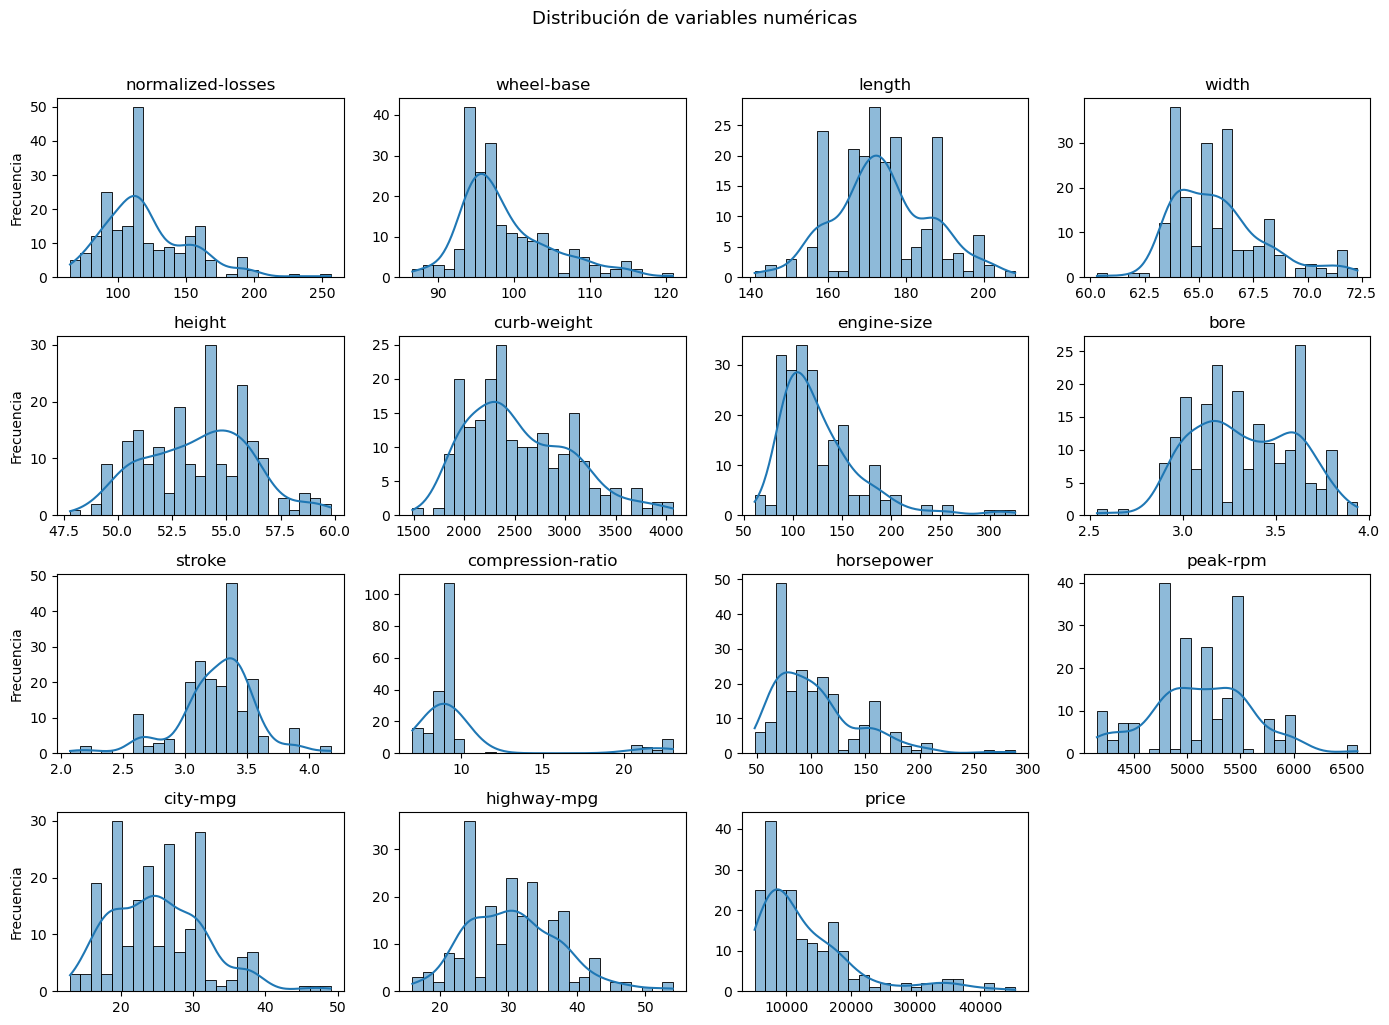

In [13]:
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(f_numericas):
    ax = axes[i]
    sns.histplot(
        data=auto,
        x=feat,
        kde=True,
        alpha=0.5,
        bins=25,
        ax=axes[i],
        legend=(i == 0),
    )
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia" if i % 4 == 0 else "")

# Elimina los ejes que quedaron sin usar
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribución de variables numéricas", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

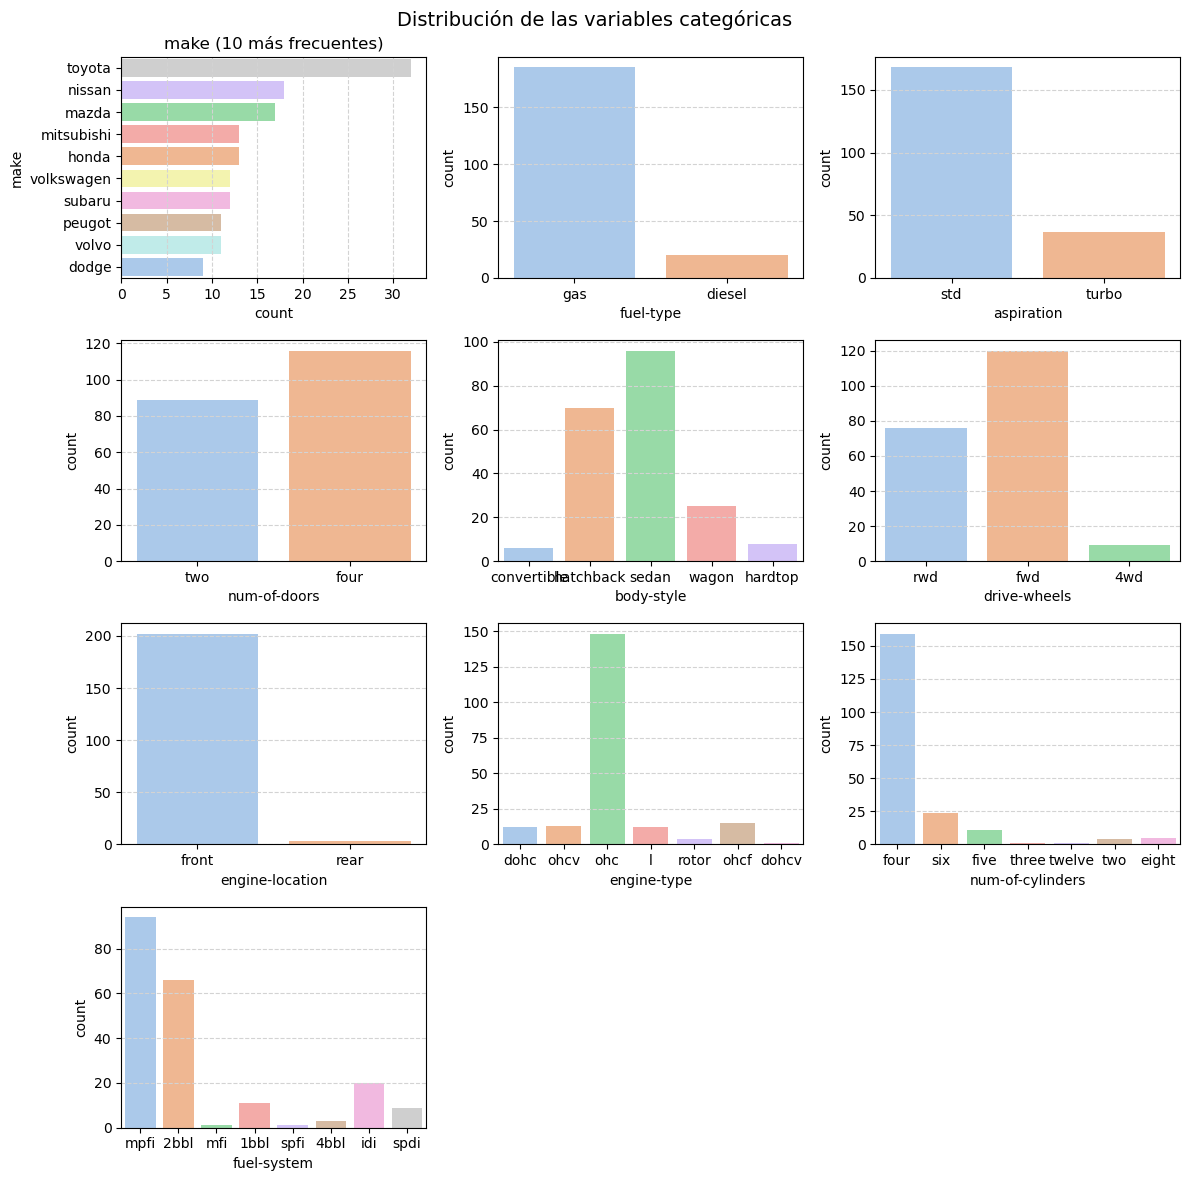

In [15]:
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.flatten()  

for i, cat in enumerate(f_categoricas):
    if auto[cat].nunique() > 10:
        top = auto[cat].value_counts().head(10)
        orden = top.index
        sns.countplot(
            y=cat,
            data=auto[auto[cat].isin(orden)],
            hue=cat,
            order=orden,
            palette='pastel',
            ax=axes[i])
        axes[i].grid(axis='x', ls='--', color='lightgray')
        axes[i].set_title(f'{cat} (10 más frecuentes)')
    else:
        sns.countplot(x=cat, data=auto, hue=cat, palette='pastel', ax=axes[i])
        axes[i].grid(axis='y', ls='--', color='lightgray')

# Elimina los ejes que quedaron sin usar
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
    
plt.suptitle('Distribución de las variables categóricas', fontsize=14)
plt.tight_layout()
plt.show()

---
### Exploramos algunas asociaciones entre features
---

#### Correlación de Pearson

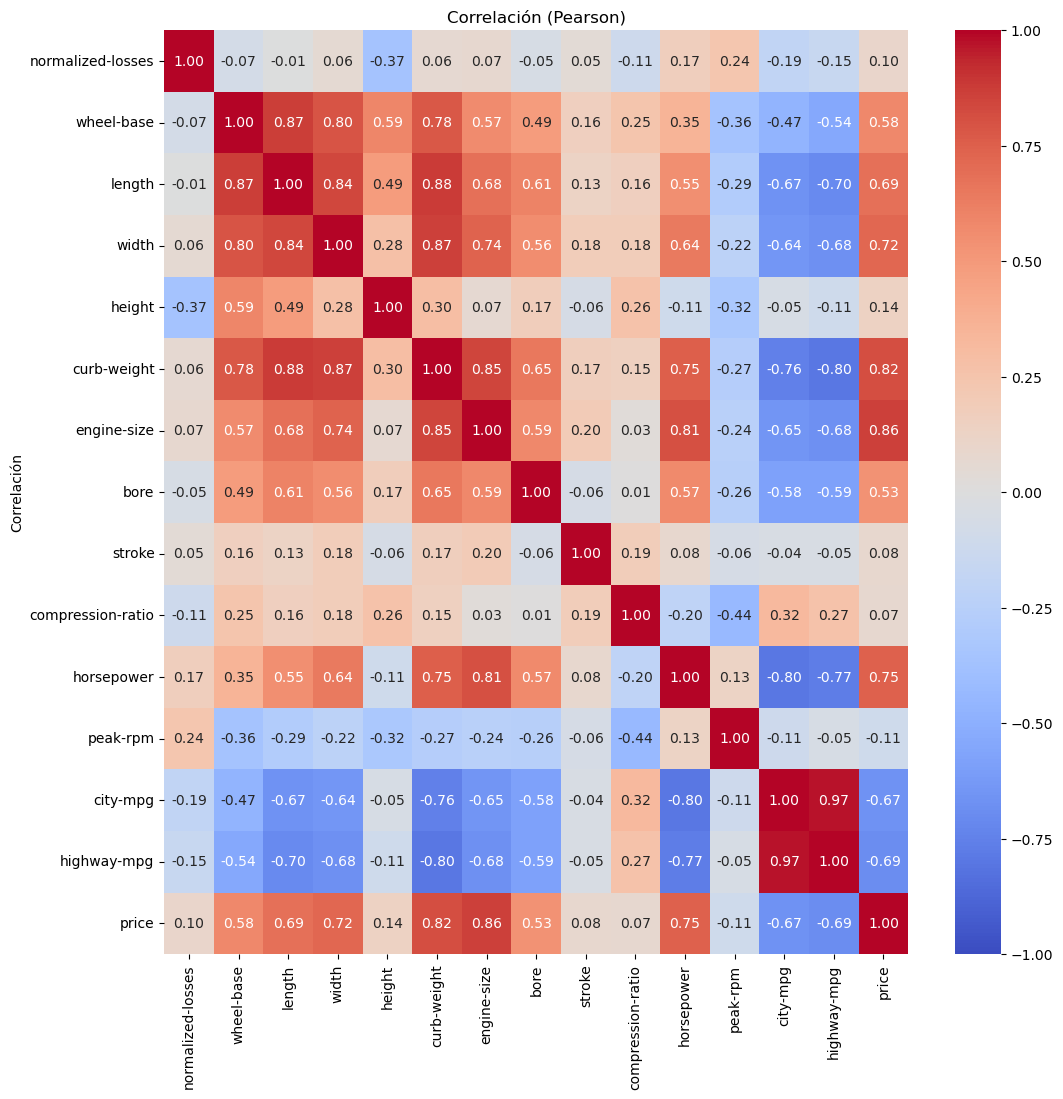

In [16]:
plt.figure(figsize=(12, 12))

sns.heatmap(
    auto[f_numericas].corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
plt.ylabel('Correlación')
plt.title("Correlación (Pearson)")
plt.show()

#### Asociación eta cuadrado (numérica - categórica)

In [17]:
from scipy.stats import f_oneway

def eta_squared(continuous, categorical):
    mask       = continuous.notna() & categorical.notna()
    y, grp     = continuous[mask], categorical[mask]
    groups     = [g.values for _, g in y.groupby(grp, observed=True)]
    F, p       = f_oneway(*groups)
    grand_mean = y.mean()
    ss_total   = ((y - grand_mean) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    return ss_between / ss_total, p, F

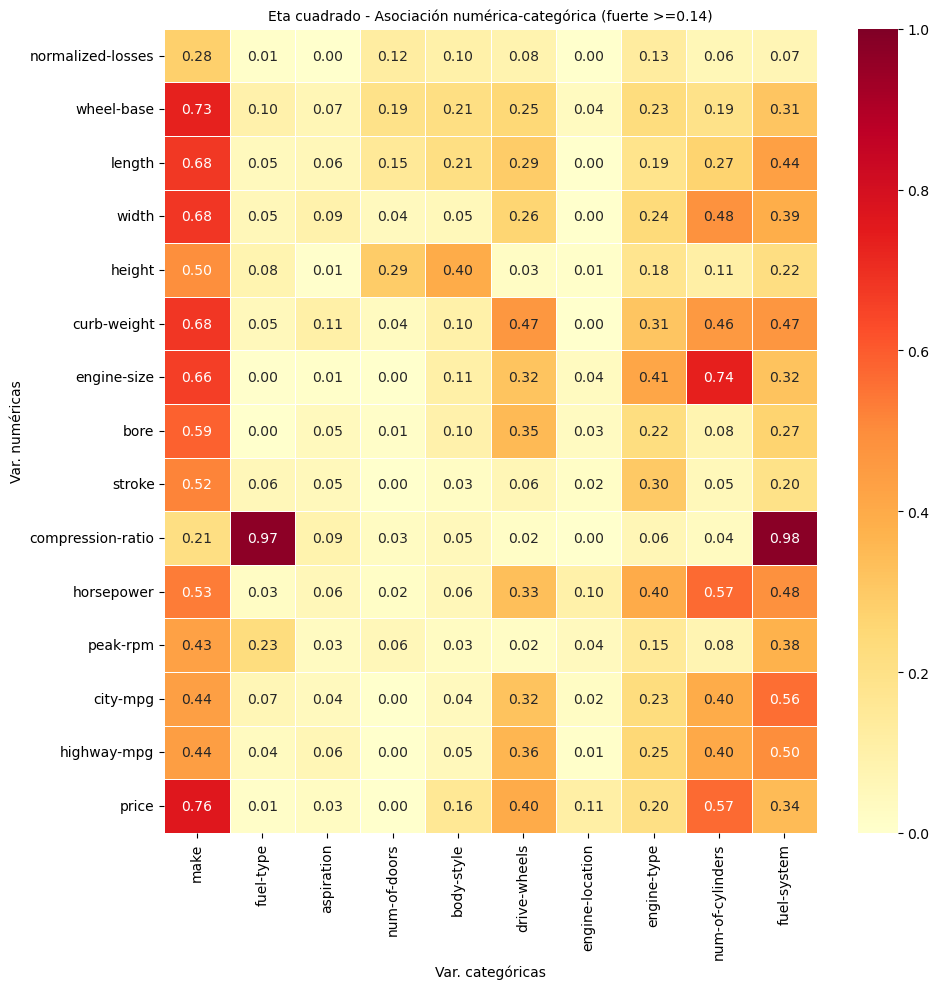

In [21]:
resultados = {}
for num_col in f_numericas:
    for cat_col in f_categoricas:
        eta2, p, F = eta_squared(auto[num_col], auto[cat_col])
        resultados[(num_col, cat_col)] = eta2

# Matriz de resultados
eta2_mat = pd.DataFrame(
    {cat: {num: resultados[(num, cat)] for num in f_numericas} for cat in f_categoricas}
)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(eta2_mat, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)

ax.set_title("Eta cuadrado - Asociación numérica-categórica (fuerte >=0.14)", fontsize=10)
ax.set_xlabel("Var. categóricas")
ax.set_ylabel("Var. numéricas")
plt.tight_layout()
plt.show()

#### Cramer's V (fuerza de asoc. categórica - categórica)

In [27]:
# Función para calcular Cramér's V entre dos variables categóricas x e y
from scipy.stats import chi2_contingency
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * min(k - 1, r - 1)))


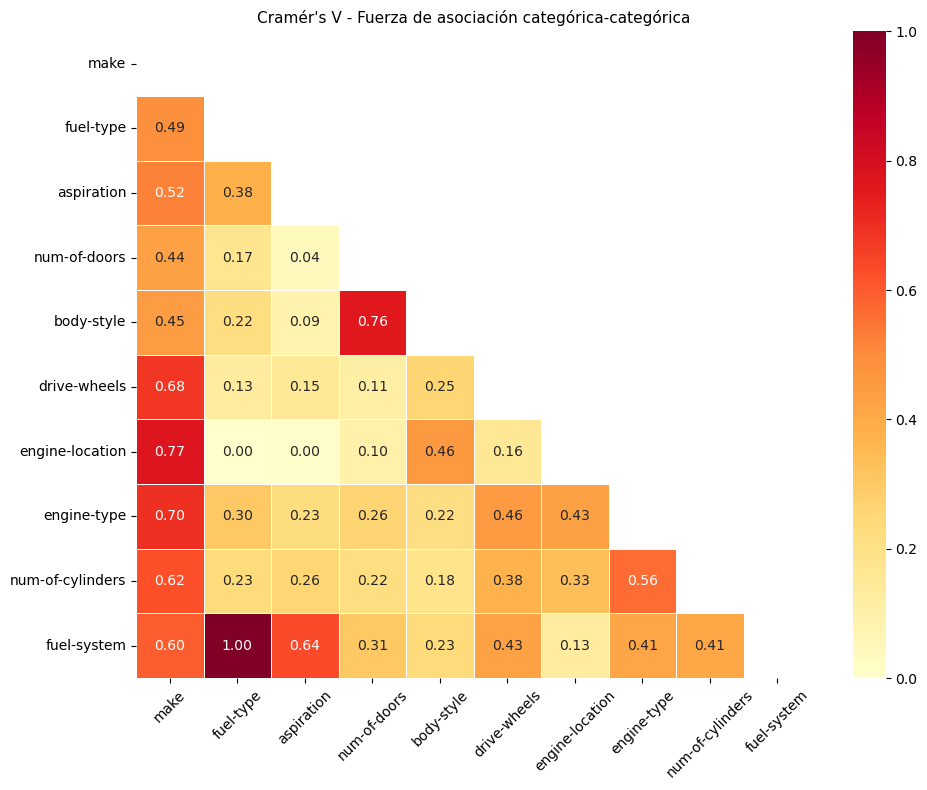

In [31]:
cat_cols = f_categoricas

v_mat = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for c1 in cat_cols:
    for c2 in cat_cols:
        if c1 == c2:
            v_mat.loc[c1, c2] = 1.0
        else:
            mask = auto[c1].notna() & auto[c2].notna()
            v_mat.loc[c1, c2] = cramers_v(
                auto.loc[mask, c1], auto.loc[mask, c2]
            )

# Máscara para mostrar solo la mitad inferior de la matriz
mask = np.triu(np.ones_like(v_mat, dtype=bool))

# Dibujamos la matriz con heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(v_mat.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5,
            mask=mask, ax=ax)

ax.set_title("Cramér's V - Fuerza de asociación categórica-categórica", fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
